In [54]:
import math
import random
import heapq
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [55]:
# ==========================================================
# 1. KONFIGURASI SISTEM & GENERASI ENTITAS
# ==========================================================
random.seed(42)
np.random.seed(42)

NUM_HOUSES = 100
GRID_SIZE = 30 
NUM_TPS = 3
NUM_GARTS = 7
NUM_TRUCKS = 4

TIME_GAR_START = 6 * 60  
TIME_GAR_END = 15 * 60    
TIME_TRK_START = 8 * 60  
TIME_TRK_END = 17 * 60    

class Entity:
    def __init__(self, id_ent, x, y):
        self.id = id_ent
        self.x = x
        self.y = y

class House(Entity):
    def __init__(self, id_ent, x, y):
        super().__init__(id_ent, x, y)
        self.waste = random.uniform(0.1, 7.0)

class TPS(Entity):
    def __init__(self, id_ent, x, y):
        super().__init__(id_ent, x, y)
        self.cap = 500.0 
        self.load = 0.0

class Vehicle:
    def __init__(self, id_ent, vtype, cap, start_t, end_t, speed_min_per_dist, load_min_per_kg, home_tps):
        self.id = id_ent
        self.vtype = vtype
        self.cap = cap
        self.load = 0
        self.t = start_t
        self.start_t = start_t
        self.end_t = end_t
        self.speed = speed_min_per_dist
        self.load_time = load_min_per_kg
        self.dist_traveled = 0
        self.log = []
        self.home_tps = home_tps
        self.node_id = home_tps.id
        self.is_done = False # PERBAIKAN: Penanda jika agen sudah selesai sebelum waktunya

def get_euclidean(p1, p2):
    return math.hypot(p1.x - p2.x, p1.y - p2.y)

houses = [House(f"H{i+1}", random.uniform(0, GRID_SIZE), random.uniform(0, GRID_SIZE)) for i in range(NUM_HOUSES)]
tps_coords = [(5, 5), (GRID_SIZE-5, GRID_SIZE-5), (GRID_SIZE/2, GRID_SIZE-5)]
tps_list = [TPS(f"TPS-{i+1}", tps_coords[i][0], tps_coords[i][1]) for i in range(NUM_TPS)]

all_nodes = houses + tps_list
nodes_dict = {n.id: n for n in all_nodes}

truck_dist = [2, 1, 1]
gart_dist = [3, 2, 2]

trucks, t_idx = [], 1
for i, count in enumerate(truck_dist):
    for _ in range(count):
        trucks.append(Vehicle(f"Truk-{t_idx}", "Truk", 200, TIME_TRK_START, TIME_TRK_END, 3.0/5.0, 2.0/10.0, tps_list[i]))
        t_idx += 1

carts, c_idx = [], 1
for i, count in enumerate(gart_dist):
    for _ in range(count):
        carts.append(Vehicle(f"Gerobak-{c_idx}", "Gerobak", 15, TIME_GAR_START, TIME_GAR_END, 3.0, 2.0, tps_list[i]))
        c_idx += 1

all_vehicles = carts + trucks

In [56]:
# ==========================================================
# 2. PEMBANGUNAN JARINGAN GRAF JALAN REALISTIS
# ==========================================================
graph = {n.id: {} for n in all_nodes}
seen_edges = set()

def add_edge(n1, n2, weight):
    graph[n1.id][n2.id] = weight
    graph[n2.id][n1.id] = weight
    seen_edges.add(tuple(sorted((n1.id, n2.id))))

for h in houses:
    distances = [(get_euclidean(h, other), other) for other in houses if h.id != other.id]
    distances.sort(key=lambda x: x[0])
    for i in range(min(2, len(distances))):
        add_edge(h, distances[i][1], distances[i][0])

for h in houses:
    tps_distances = [(get_euclidean(h, t), t) for t in tps_list]
    tps_distances.sort(key=lambda x: x[0])
    add_edge(h, tps_distances[0][1], tps_distances[0][0])

for i in range(len(tps_list)):
    for j in range(i+1, len(tps_list)):
        add_edge(tps_list[i], tps_list[j], get_euclidean(tps_list[i], tps_list[j]))

def get_shortest_paths(start_node_id):
    distances = {node: float('inf') for node in graph}
    distances[start_node_id] = 0
    pq = [(0, start_node_id)]
    
    while pq:
        curr_dist, curr_node = heapq.heappop(pq)
        if curr_dist > distances[curr_node]: continue
        for neighbor, weight in graph[curr_node].items():
            dist = curr_dist + weight
            if dist < distances[neighbor]:
                distances[neighbor] = dist
                heapq.heappush(pq, (dist, neighbor))
    return distances

Membangun jaringan graf jalan realistis...


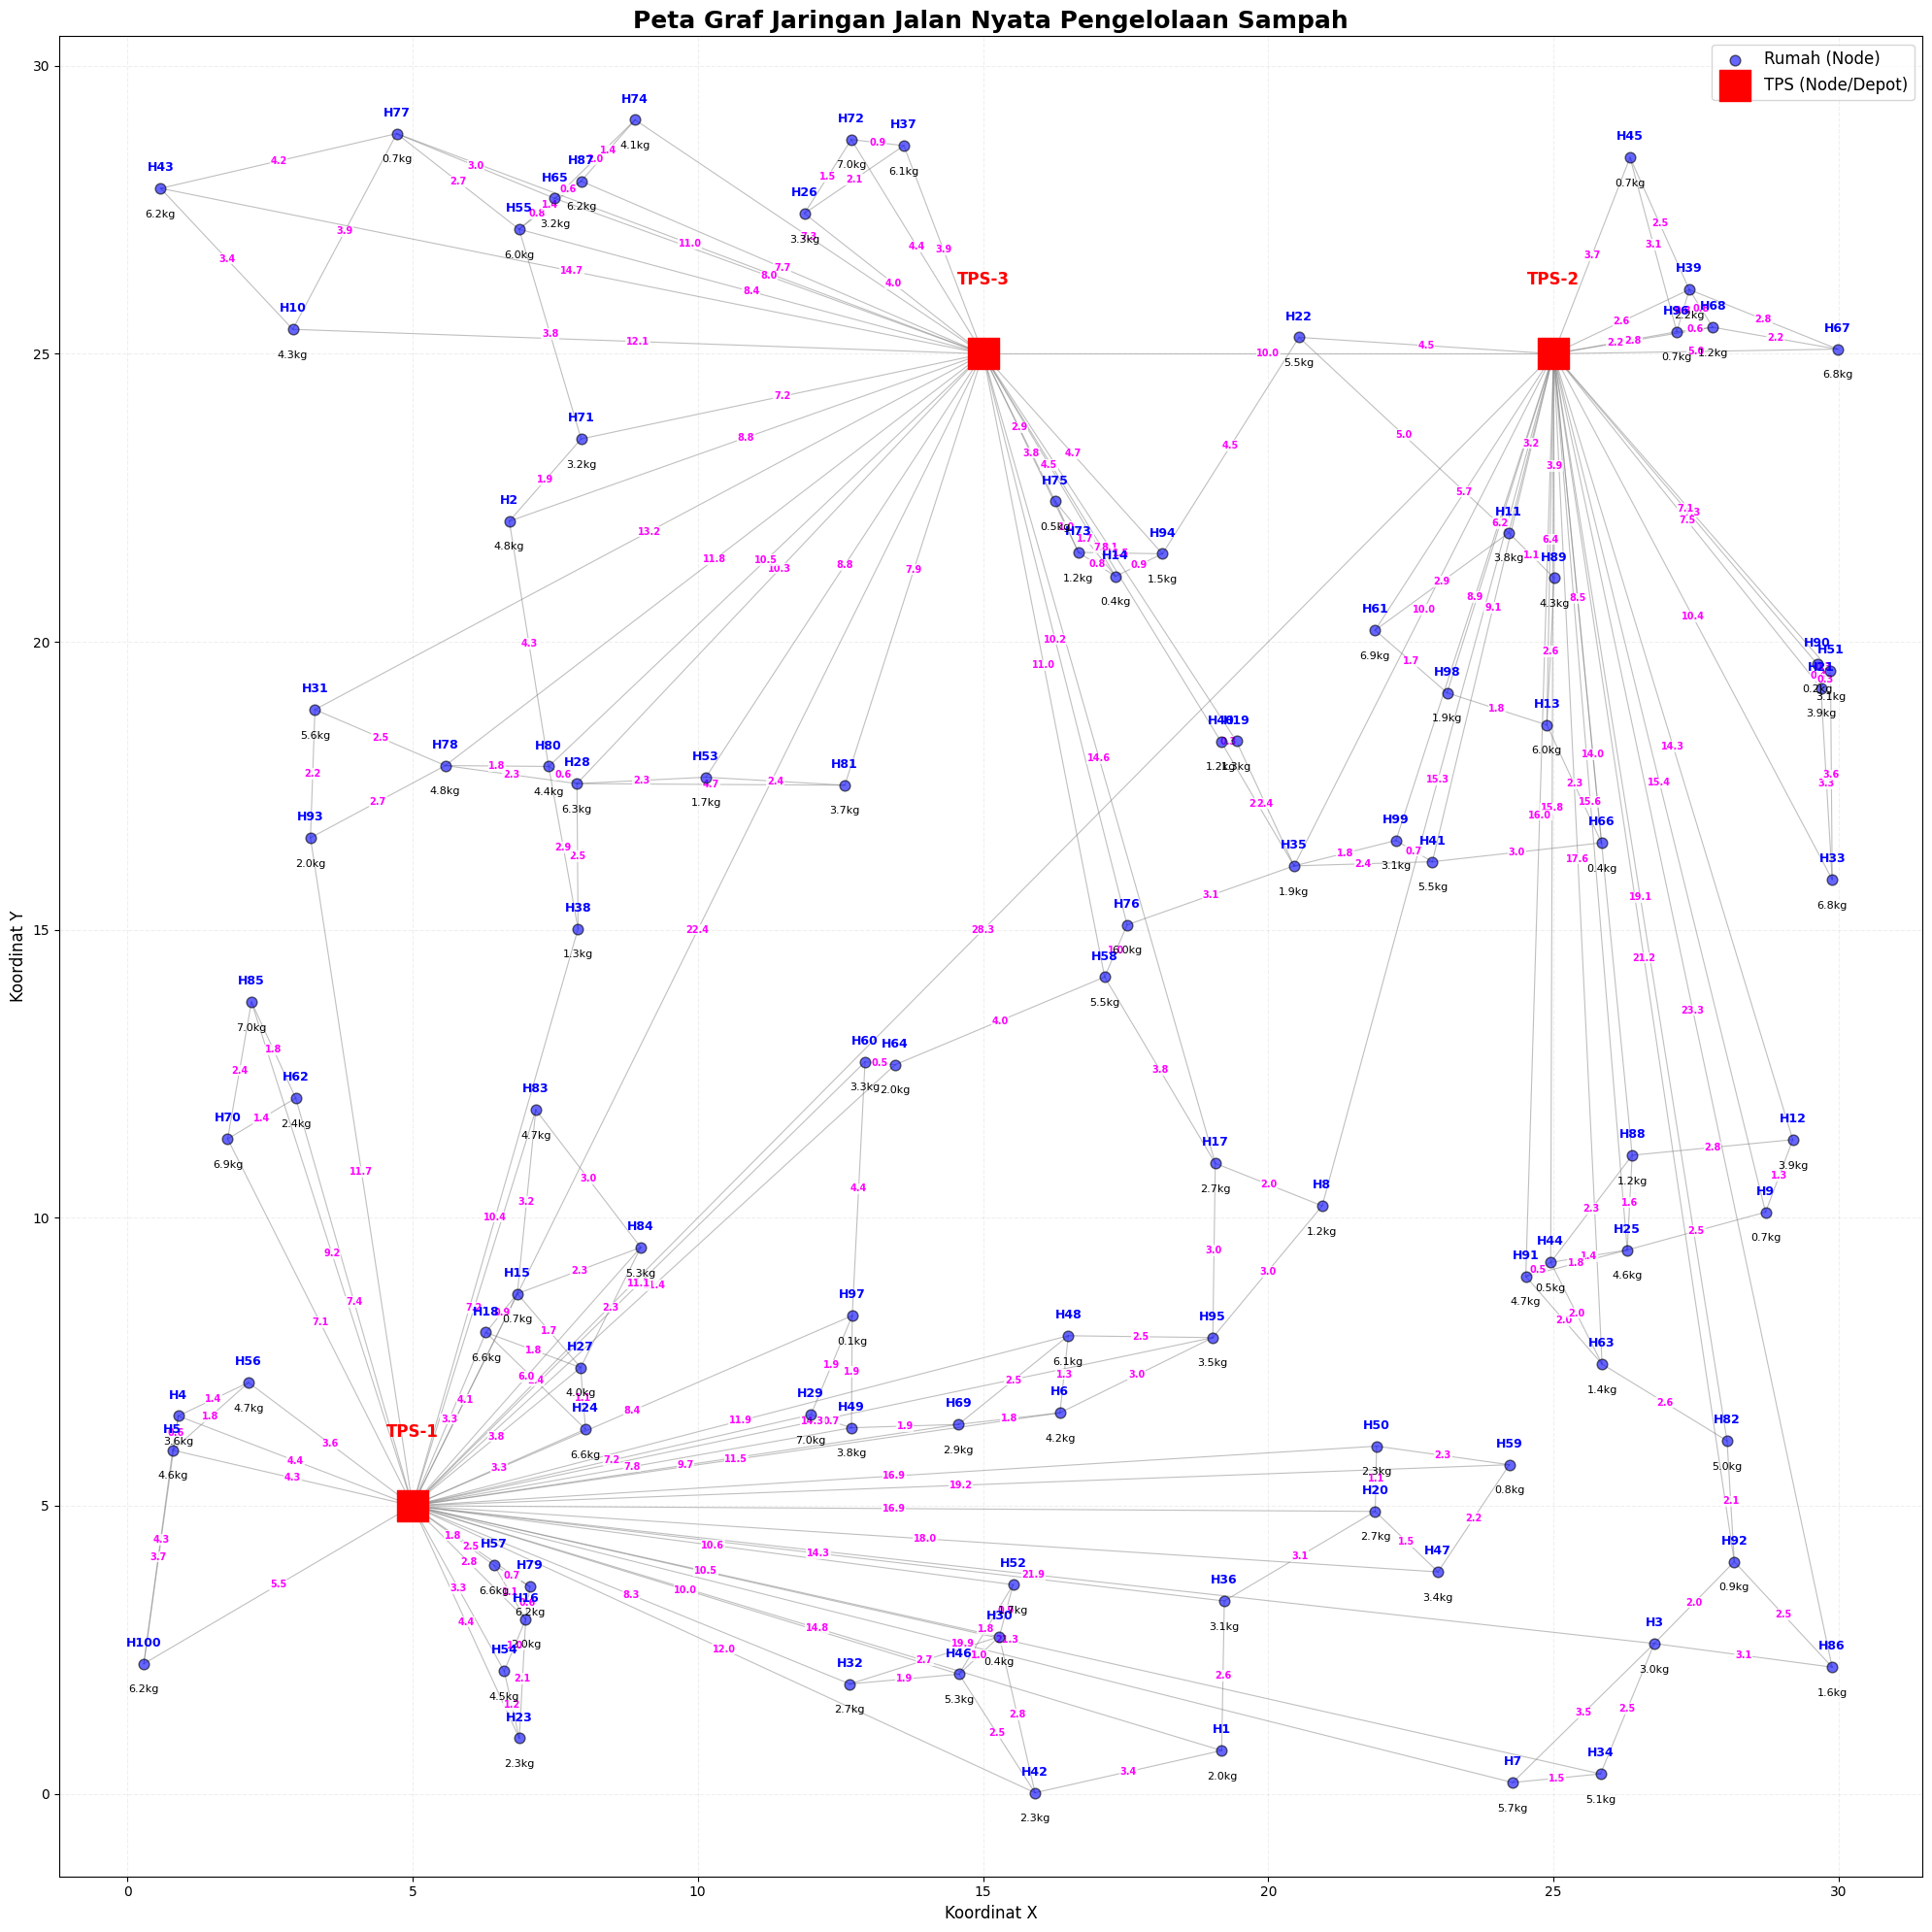

In [57]:
# ==========================================================
# 3. VISUALISASI PETA
# ==========================================================
def plot_realistic_map():
    plt.figure(figsize=(20, 20))
    for edge in seen_edges:
        n1, n2 = nodes_dict[edge[0]], nodes_dict[edge[1]]
        weight = graph[n1.id][n2.id]
        plt.plot([n1.x, n2.x], [n1.y, n2.y], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
        mid_x, mid_y = (n1.x + n2.x)/2, (n1.y + n2.y)/2
        plt.text(mid_x, mid_y, f"{weight:.1f}", color='magenta', fontsize=7, fontweight='bold', ha='center', va='center',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.5))

    plt.scatter([h.x for h in houses], [h.y for h in houses], c='blue', s=60, label='Rumah (Node)', alpha=0.6, edgecolors='black', zorder=5)
    for h in houses:
        plt.text(h.x, h.y + 0.3, f"{h.id}", fontsize=9, color='blue', ha='center', fontweight='bold', zorder=6)
        plt.text(h.x, h.y - 0.5, f"{h.waste:.1f}kg", fontsize=8, color='black', ha='center', zorder=6)

    plt.scatter([t.x for t in tps_list], [t.y for t in tps_list], c='red', marker='s', s=500, label='TPS (Node/Depot)', zorder=10)
    for t in tps_list:
        plt.text(t.x, t.y + 1.2, f"{t.id}", fontsize=12, color='red', ha='center', fontweight='bold', zorder=11)

    plt.title('Peta Graf Jaringan Jalan Nyata Pengelolaan Sampah', fontsize=18, fontweight='bold')
    plt.xlabel('Koordinat X', fontsize=12)
    plt.ylabel('Koordinat Y', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()

print("Membangun jaringan graf jalan realistis...")
plot_realistic_map()

In [58]:
# ==========================================================
# 4. SIMULASI GREEDY BFS (DIJKSTRA) DENGAN WAKTU REALISTIS
# ==========================================================
print("\nMengeksekusi simulasi pergerakan armada sesuai jalan (Graph-based)...")

for v in all_vehicles:
    v.log.append([v.t, "Mulai Sif", f"Berangkat dari pangkalan {v.node_id}"])

while True:
    # PERBAIKAN: Hanya proses agen yang waktunya belum habis DAN belum ditandai selesai (is_done=False)
    active_v = [v for v in all_vehicles if v.t < v.end_t and not v.is_done]
    if not active_v: break
    
    active_v.sort(key=lambda v: v.t)
    v = active_v[0] 

    total_waste_left = sum(h.waste for h in houses if h.waste > 0.01)
    is_closing_time = total_waste_left < 0.1 
    
    path_distances = get_shortest_paths(v.node_id)

    # KONDISI 1: Pengosongan Muatan
    if v.load >= v.cap * 0.9 or (is_closing_time and v.load > 0):
        all_tps_sorted = sorted(tps_list, key=lambda t: path_distances[t.id])
        target_node = None
        is_tps = True
        
        for t in all_tps_sorted:
            if t.cap - t.load >= v.load: 
                target_node = t
                break
                
        if target_node is None:
            v.log.append([v.t, "Darurat", "Seluruh TPS penuh kapasitas!"])
            v.is_done = True
            continue
            
        if v.vtype == "Gerobak" and not is_closing_time:
            valid_trucks = [trk for trk in trucks if trk.t >= TIME_TRK_START and trk.t < trk.end_t and trk.cap - trk.load >= v.load and not trk.is_done]
            if valid_trucks:
                nearest_trk = min(valid_trucks, key=lambda trk: path_distances[trk.node_id])
                if path_distances[nearest_trk.node_id] < path_distances[target_node.id]:
                    target_node = nearest_trk
                    is_tps = False
        
        d_travel = path_distances[target_node.id if is_tps else target_node.node_id]
        t_travel = d_travel * v.speed
        dump_amt = v.load
        t_action = dump_amt * v.load_time
        
        if v.t + t_travel + t_action > v.end_t:
            v.is_done = True
            continue
            
        v.t += t_travel + t_action
        v.dist_traveled += d_travel
        v.node_id = target_node.id if is_tps else target_node.node_id
        
        if is_tps:
            target_node.load += dump_amt
            v.log.append([v.t, "Setor Sampah", f"Menurunkan {dump_amt:.1f} kg di {target_node.id} via jalan darat"])
        else:
            target_node.load += dump_amt
            v.log.append([v.t, "Rendezvous", f"Menemui {target_node.id} di Node {v.node_id} untuk transfer {dump_amt:.1f} kg"])
            target_node.log.append([max(v.t, target_node.t), "Terima Transfer", f"Menerima {dump_amt:.1f} kg dari {v.id} di Node {v.node_id}"])
            target_node.t = max(target_node.t, v.t)
            
        v.load = 0

    # KONDISI 2: Penjemputan Sampah ke Rumah
    else:
        valid_houses = [h for h in houses if h.waste > 0.01]
        
        # PERBAIKAN WAKTU: Jika rumah sudah bersih, biarkan agen pensiun TANPA mengubah waktunya
        if not valid_houses:
            v.is_done = True 
            continue
            
        target_h = min(valid_houses, key=lambda h: path_distances[h.id])
        d_travel = path_distances[target_h.id]
        t_travel = d_travel * v.speed
        pick_amt = min(v.cap - v.load, target_h.waste)
        t_action = pick_amt * v.load_time
        
        if v.t + t_travel + t_action > v.end_t:
            v.is_done = True
            continue
            
        v.t += t_travel + t_action
        v.dist_traveled += d_travel
        v.node_id = target_h.id
        target_h.waste -= pick_amt
        v.load += pick_amt
        v.log.append([v.t, "Angkut Sampah", f"Mengambil {pick_amt:.1f} kg dari {target_h.id}"])

# PENYELESAIAN REALISTIS: Pulang ke TPS Markas dengan penambahan waktu perjalanan aktual
for v in all_vehicles:
    final_paths = get_shortest_paths(v.node_id)
    d_return = final_paths[v.home_tps.id]
    t_return = d_return * v.speed
    v.dist_traveled += d_return
    v.t += t_return # Waktu bertambah sesuai durasi kepulangan aktual
    
    status_pulang = "Selesai Bertugas (Pulang Awal)" if v.t <= v.end_t else "Terlambat Kembali (Overtime)"
    v.log.append([v.t, status_pulang, f"Tiba di {v.home_tps.id}. Sisa muatan: {v.load:.1f} kg"])

print("Simulasi Jaringan Selesai.")


Mengeksekusi simulasi pergerakan armada sesuai jalan (Graph-based)...
Simulasi Jaringan Selesai.


In [59]:
# ==========================================================
# 5. LAPORAN TRANSPARANSI
# ==========================================================
def format_time_log(min_from_zero):
    return f"{int(min_from_zero // 60):02d}:{int(min_from_zero % 60):02d}"

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("\n" + "="*80)
print("     LAPORAN TRANSPARANSI BERBASIS PERGERAKAN JALAN NYATA (DIJKSTRA)")
print("="*80)

sisa_rumah = sum(h.waste for h in houses)
total_tps_collected = sum(t.load for t in tps_list)

print("\n[A] STATUS SAMPAH DAN TEMPAT PEMBUANGAN AKHIR (TPS)")
print("-" * 60)
print(f"Sisa Sampah di Area Perumahan Warga   : {sisa_rumah:.2f} kg")
print(f"Total Keseluruhan Sampah di Semua TPS : {total_tps_collected:.2f} kg\n")

tps_summary = []
for t in tps_list:
    status_penuh = "Kritis/Penuh!" if t.load >= t.cap else "Aman"
    tps_summary.append({
        "Nama TPS": t.id,
        "Kapasitas Maksimal": f"{t.cap:.1f} kg",
        "Sampah Tertampung": f"{t.load:.1f} kg",
        "Kapasitas Tersisa": f"{(t.cap - t.load):.1f} kg",
        "Status": status_penuh
    })
display(pd.DataFrame(tps_summary))

print("\n[B] RINGKASAN KINERJA ARMADA (KEMBALI KE TPS MARKAS)")
print("-" * 60)
summary_list = []
for v in all_vehicles:
    summary_list.append({
        "ID Agen": v.id,
        "Markas": v.home_tps.id,
        "Total Jarak Graf (Satuan)": f"{v.dist_traveled:.2f}",
        "Sampah Gantung": f"{v.load:.2f} kg",
        "Waktu Parkir (Kembali)": format_time_log(v.t) # Sekarang menampilkan waktu aktual yang rasional!
    })
display(pd.DataFrame(summary_list))

print("\n[C] LOG PERGERAKAN LENGKAP (MENGIKUTI NODE GRAF JALAN)")
print("-" * 60)
raw_logs = []
for v in all_vehicles:
    for item in v.log:
        raw_logs.append({
            "Waktu Pas": item[0],
            "Waktu (Jam)": format_time_log(item[0]),
            "Nama Agen": v.id,
            "Jenis Tindakan": item[1],
            "Detail Rute Node": item[2]
        })

df_master_log = pd.DataFrame(raw_logs).sort_values(by="Waktu Pas")
df_master_log = df_master_log[["Waktu (Jam)", "Nama Agen", "Jenis Tindakan", "Detail Rute Node"]].reset_index(drop=True)
display(df_master_log)


     LAPORAN TRANSPARANSI BERBASIS PERGERAKAN JALAN NYATA (DIJKSTRA)

[A] STATUS SAMPAH DAN TEMPAT PEMBUANGAN AKHIR (TPS)
------------------------------------------------------------
Sisa Sampah di Area Perumahan Warga   : 0.00 kg
Total Keseluruhan Sampah di Semua TPS : 353.63 kg



,Nama TPS,Kapasitas Maksimal,Sampah Tertampung,Kapasitas Tersisa,Status
0,TPS-1,500.0 kg,68.4 kg,431.6 kg,Aman
1,TPS-2,500.0 kg,270.3 kg,229.7 kg,Aman
2,TPS-3,500.0 kg,15.0 kg,485.0 kg,Aman



[B] RINGKASAN KINERJA ARMADA (KEMBALI KE TPS MARKAS)
------------------------------------------------------------


,ID Agen,Markas,Total Jarak Graf (Satuan),Sampah Gantung,Waktu Parkir (Kembali)
0,Gerobak-1,TPS-1,124.68,0.00 kg,13:49
1,Gerobak-2,TPS-1,80.33,0.00 kg,11:58
2,Gerobak-3,TPS-1,83.45,0.00 kg,11:52
3,Gerobak-4,TPS-2,71.18,0.00 kg,10:56
4,Gerobak-5,TPS-2,57.97,0.00 kg,09:58
5,Gerobak-6,TPS-3,76.32,0.00 kg,10:51
6,Gerobak-7,TPS-3,96.88,0.00 kg,12:25
7,Truk-1,TPS-1,147.92,0.00 kg,09:48
8,Truk-2,TPS-1,142.96,0.00 kg,09:47
9,Truk-3,TPS-2,136.00,0.00 kg,09:37



[C] LOG PERGERAKAN LENGKAP (MENGIKUTI NODE GRAF JALAN)
------------------------------------------------------------


,Waktu (Jam),Nama Agen,Jenis Tindakan,Detail Rute Node
0,06:00,Gerobak-1,Mulai Sif,Berangkat dari pangkalan TPS-1
1,06:00,Gerobak-2,Mulai Sif,Berangkat dari pangkalan TPS-1
2,06:00,Gerobak-3,Mulai Sif,Berangkat dari pangkalan TPS-1
3,06:00,Gerobak-4,Mulai Sif,Berangkat dari pangkalan TPS-2
4,06:00,Gerobak-5,Mulai Sif,Berangkat dari pangkalan TPS-2
5,06:00,Gerobak-6,Mulai Sif,Berangkat dari pangkalan TPS-3
6,06:00,Gerobak-7,Mulai Sif,Berangkat dari pangkalan TPS-3
7,06:08,Gerobak-4,Angkut Sampah,Mengambil 0.7 kg dari H96
8,06:09,Gerobak-6,Angkut Sampah,Mengambil 0.5 kg dari H75
9,06:12,Gerobak-5,Angkut Sampah,Mengambil 2.2 kg dari H39
